# Assignment 01: ResNet 18 vs ViT

**Available:** Aug 19, 2025 4:30pm until Aug 28, 2025 11:59pm

## Tasks:

1. Train on Human Action Recognition (40%) https://www.kaggle.com/datasets/shashankrapolu/human-Links to an external site.action-recognition-dataset/dataLinks to an external site.​
2. Evaluation on test set human-action-recognition​: 15 classes, 218 MB, 12600 images, train/test split available​
3. ResNet 18 vs ViT​
4. Report and code zip (10%)​
5. Errors and obstacles faced running the model​
6. Must have conda requirement.txt, cli commands to generate the evaluation results above (random checks will be perform to verify)​
7. Training log​
8. Video of live demo (20%)​
9. The video should comprise of visual outputs (e.g., a text "cat" overlay on the image being classified that has a cat in it)​
10. Insights (30%)​
11. ResNet vs ViT​ Computational comparisons​
12. Why one is better ...


### Import Libraries

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd

# Install einops for tensor manipulation
%pip install einops

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    # Install huggingface_hub if not already installed
    %pip install huggingface_hub
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"✅ Successfully authenticated with Hugging Face!")
        print(f"👤 Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None

# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables
Note: you may need to restart the kernel to use updated packages.


/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Successfully authenticated with Hugging Face!
👤 Logged in as: malneyugnfl

=== GPU Diagnostics ===
PyTorch version: 2.5.1
CUDA available: True
CUDA version: 12.4
Number of GPUs detected: 2

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

GPU 1:
  Name: NVIDIA RTX A6000
  Total Memory: 47.53 GB
  Multi-processor count: 84
  Compute Capability: 8.6

Using GPU 1: NVIDIA RTX A6000
Selected device: cuda:1


### Import and Process Human Action Recognition Dataset

In [2]:
## Import dataset and process it

class ActionRecognitionDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Custom dataset for Human Action Recognition with labels
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0],
                    'label': row[1]
                })
        
        # Get unique class names and create class-to-index mapping
        unique_labels = set(row['label'] for row in self.annotations)
        self.classes = sorted(list(unique_labels))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        print(f"Found {len(self.classes)} classes: {self.classes}")
        print(f"Total samples: {len(self.annotations)}")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename and label from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        label_name = annotation['label']
        
        # Convert label name to index
        label = self.class_to_idx[label_name]
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

class TestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Test dataset for Human Action Recognition without labels (for prediction)
        Args:
            csv_file (string): Path to the csv file with filenames only.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        import csv
        
        self.root_dir = root_dir
        self.transform = transform
        
        # Read CSV manually to avoid pandas compatibility issues
        self.annotations = []
        with open(csv_file, 'r') as file:
            reader = csv.reader(file)
            headers = next(reader)  # Skip header
            for row in reader:
                self.annotations.append({
                    'filename': row[0]
                })
        
        print(f"Found {len(self.annotations)} test images")
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
            
        # Get image filename from annotations
        annotation = self.annotations[idx]
        img_name = annotation['filename']
        
        # Construct full image path
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = PIL.Image.open(img_path)
        
        # Convert RGBA to RGB if necessary
        if image.mode == 'RGBA':
            image = image.convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, img_name  # Return image and filename for prediction

# Data transforms with proper normalization for RGB images
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # Converts PIL to tensor and scales to [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Define data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Dataset classes updated to avoid pandas compatibility issues!")

Dataset classes updated to avoid pandas compatibility issues!


In [3]:
# Fix for pandas CSV reading issue
# This error often occurs due to version incompatibility between pandas and numpy
# Let's try reading the CSV with a different engine or method

import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Try to read a sample CSV to test if the issue persists
try:
    test_df = pd.read_csv('data/Training_set.csv', engine='python')
    print(f"CSV reading test successful! Found {len(test_df)} rows")
    print(f"Columns: {list(test_df.columns)}")
    print(f"First 3 rows:\n{test_df.head(3)}")
except Exception as e:
    print(f"CSV reading still fails: {e}")
    print("Trying alternative solution...")

Pandas version: 2.3.2
NumPy version: 2.2.6
CSV reading test successful! Found 12600 rows
Columns: ['filename', 'label']
First 3 rows:
      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging


In [4]:
# Create datasets
train_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=train_transform
)

# For this assignment, we'll create validation data from training data
# Split training data into train and validation (80-20 split)
from torch.utils.data import random_split

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

# Create validation dataset with test transforms (no augmentation)
val_data = ActionRecognitionDataset(
    csv_file='data/Training_set.csv',
    root_dir='data/train',
    transform=data_transform
)

# Extract validation indices for proper subset
val_dataset = torch.utils.data.Subset(val_data, val_subset.indices)

# Create test dataset and loader for final evaluation
test_data = TestDataset(
    csv_file='data/Testing_set.csv',
    root_dir='data/test',
    transform=data_transform  # No augmentation for test data
)

print(f"\nDataset Information:")
print(f"Total training samples: {len(train_data)}")
print(f"Training subset: {len(train_subset)}")
print(f"Validation subset: {len(val_dataset)}")
print(f"Number of classes: {len(train_data.classes)}")
print(f"Classes: {train_data.classes}")
print(f"\nTest Dataset Information:")
print(f"Test samples: {len(test_data)}")


# Test loading a sample
try:
    sample_image, sample_label = train_data[0]
    print(f"\nSample check:")
    print(f"Image shape: {sample_image.shape}")
    print(f"Label: {sample_label} ({train_data.classes[sample_label]})")
except Exception as e:
    print(f"Error loading sample: {e}")
    print("Please check if the image files exist in the correct directory")

# Test loading from test dataset
try:
    test_sample_image, test_filename = test_data[0]
    print(f"\nTest Sample Check:")
    print(f"Test image shape: {test_sample_image.shape}")
    print(f"Test filename: {test_filename}")
    print("Test dataset loading successful!")
except Exception as e:
    print(f"Error loading test sample: {e}")
    print("Please check if the test image files exist in the correct directory")

Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Total samples: 12600
Found 5400 test images

Dataset Information:
Total training samples: 12600
Training subset: 10080
Validation subset: 2520
Number of classes: 15
Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']

Test Dataset Information:
Test samples: 5400

Sample check:
Image shape: torch.Size([3, 224, 224])
Label: 11 (sitting)

Test Sample Check:
Test image shape: torch.Size([3, 224, 224])
Test filename: Image_1.jpg


### Create Dataloaders that will be used for ResNet 18 and ViT

In [5]:
# Create data loaders
batch_size = 50
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)


print(f"\nData Loaders:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Data Loaders:
Training batches: 202
Validation batches: 51
Test batches: 108


### Import ResNet 18

In [6]:
resnet18= torchvision.models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, len(train_data.classes))  # Adjust final layer for 15 classes
resnet18 = resnet18.to(device)

### Import ViT

In [7]:
# Import and Setup ViT

# Import and Setup ViT
# Install timm (PyTorch Image Models) for Vision Transformer
%pip install timm

import timm
import torch
import torch.nn as nn

# Define number of classes for Human Action Recognition
num_classes = len(train_data.classes)  # Should be 15 classes

print("=== Setting up Vision Transformer ===")

# Try to load a pre-trained Vision Transformer, fallback to non-pretrained if authorization fails
try:
    print("Attempting to load pre-trained ViT model...")
    vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    print("Pre-trained ViT model loaded successfully!")
except Exception as e:
    print(f"Could not load pre-trained model: {e}")
    print("Loading ViT without pre-trained weights...")
    vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
    print("ViT model (without pre-training) loaded successfully!")

# Move model to device 
vit_model = vit_model.to(device)

print(f"Model: {vit_model.__class__.__name__}")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")

# Get model information
vit_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f'ViT trainable parameters in millions: {vit_params/1000000:.2f}')

# Create a sample input to test the model
print(f"\n=== Testing ViT with Sample Data ===")
try:
    # Create a dummy batch (batch_size=2, channels=3, height=224, width=224)
    sample_input = torch.randn(2, 3, 224, 224).to(device)
    print(f"Sample input shape: {sample_input.shape}")
    
    # Test forward pass
    with torch.no_grad():
        vit_output = vit_model(sample_input)
    
    print(f"ViT output shape: {vit_output.shape}")
    print(f"Expected shape: (batch_size=2, num_classes={num_classes})")
    print("ViT is ready for training!")
    
    # Display model architecture summary
    print(f"\n=== ViT Architecture Summary ===")
    print(f"Model type: Vision Transformer Base (patch size 16)")
    print(f"Input size: 224x224 pixels") 
    print(f"Patch size: 16x16 pixels")
    print(f"Number of patches: {(224//16)**2} patches")
    print(f"Embedding dimension: 768")
    print(f"Number of attention heads: 12")
    print(f"Number of transformer layers: 12")
    print(f"Output classes: {num_classes}")
    
except Exception as e:
    print(f"Error testing ViT: {e}")

print(f"\nViT is now ready to be compared with ResNet-18!")
print(f"Both models will classify images into {num_classes} human action categories:")
print(f"Classes: {train_data.classes}")

Note: you may need to restart the kernel to use updated packages.
=== Setting up Vision Transformer ===
Attempting to load pre-trained ViT model...
Pre-trained ViT model loaded successfully!
Model: VisionTransformer
Number of classes: 15
Device: cuda:1
ViT trainable parameters in millions: 85.81

=== Testing ViT with Sample Data ===
Sample input shape: torch.Size([2, 3, 224, 224])
ViT output shape: torch.Size([2, 15])
Expected shape: (batch_size=2, num_classes=15)
ViT is ready for training!

=== ViT Architecture Summary ===
Model type: Vision Transformer Base (patch size 16)
Input size: 224x224 pixels
Patch size: 16x16 pixels
Number of patches: 196 patches
Embedding dimension: 768
Number of attention heads: 12
Number of transformer layers: 12
Output classes: 15

ViT is now ready to be compared with ResNet-18!
Both models will classify images into 15 human action categories:
Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', '

### Summary of Models

In [ ]:
# Test both models with synthetic data (to avoid numpy compatibility issues)
print("Testing both models with synthetic data...")

# Create synthetic test data
batch_size_test = 2
test_images = torch.randn(batch_size_test, 3, 224, 224).to(device)
test_labels = torch.randint(0, num_classes, (batch_size_test,)).to(device)

print(f"Test batch shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Test ResNet-18
print("\nTesting ResNet-18...")
with torch.no_grad():
    resnet_output = resnet18(test_images)
    resnet_probs = torch.softmax(resnet_output, dim=1)
    resnet_preds = torch.argmax(resnet_output, dim=1)
    print(f"ResNet-18 output shape: {resnet_output.shape}")
    print(f"ResNet-18 predictions: {resnet_preds}")
    print(f"ResNet-18 max probabilities: {torch.max(resnet_probs, dim=1)[0]}")

# Test ViT
print("\nTesting ViT...")
with torch.no_grad():
    vit_output = vit_model(test_images)
    vit_probs = torch.softmax(vit_output, dim=1)
    vit_preds = torch.argmax(vit_output, dim=1)
    print(f"ViT output shape: {vit_output.shape}")
    print(f"ViT predictions: {vit_preds}")
    print(f"ViT max probabilities: {torch.max(vit_probs, dim=1)[0]}")

print("\nBoth models are working correctly!")
print(f"Ready to train on {len(train_data.classes)} classes: {train_data.classes}")

# Model comparison summary
print(f"\nModel Comparison Summary:")
resnet_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
vit_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ResNet-18 parameters: {resnet_params/1e6:.2f}M")
print(f"ViT parameters: {vit_params/1e6:.2f}M")
print(f"Parameter ratio (ViT/ResNet): {vit_params/resnet_params:.1f}x")
print(f"Training samples: {len(train_subset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_data):,}")

# Memory usage info
print(f"\nGPU Memory Usage:")
if torch.cuda.is_available():
    print(f"Allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB")
    print(f"Cached: {torch.cuda.memory_reserved(device)/1e9:.2f} GB")

🧪 Testing both models with synthetic data...
Test batch shape: torch.Size([2, 3, 224, 224])
Test labels shape: torch.Size([2])

Testing ResNet-18...
ResNet-18 output shape: torch.Size([2, 15])
ResNet-18 predictions: tensor([13, 11], device='cuda:1')
ResNet-18 max probabilities: tensor([0.1617, 0.1539], device='cuda:1')

Testing ViT...
ViT output shape: torch.Size([2, 15])
ViT predictions: tensor([2, 2], device='cuda:1')
ViT max probabilities: tensor([0.1263, 0.1434], device='cuda:1')

Both models are working correctly!
Ready to train on 15 classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']

Model Comparison Summary:
ResNet-18 parameters: 11.18M
ViT parameters: 85.81M
Parameter ratio (ViT/ResNet): 7.7x
Training samples: 10,080
Validation samples: 2,520
Test samples: 5,400

GPU Memory Usage:
Allocated: 0.40 GB
Cached: 0.47 GB


### Setup Training for ViT and ResNet-18

In [9]:
# Improved Training for ViT and ResNet-18 with Logging

import time
from collections import defaultdict
from datetime import datetime

# Set up the training parameters
learning_rate = 0.001
num_epochs = 15
patience = 5  # Early stopping patience

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=learning_rate, weight_decay=1e-4)
optimizer_vit = optim.Adam(vit_model.parameters(), lr=learning_rate, weight_decay=1e-4)

def setup_logging(model_name):
    """Setup logging to text file"""
    os.makedirs('logs', exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = f'logs/{model_name.lower().replace("-", "_")}_training_{timestamp}.log'
    return log_file

def log_message(log_file, message, print_msg=True):
    """Log message to both console and file"""
    if print_msg:
        print(message)
    
    with open(log_file, 'a', encoding='utf-8') as f:
        f.write(message + '\n')

def train_model(model, optimizer, model_name, save_checkpoints=True):
    """
    Improved training function with proper validation, early stopping, and comprehensive logging
    """
    # Setup logging
    log_file = setup_logging(model_name)
    
    # Log training start info
    log_message(log_file, f"\nStarting training for {model_name}")
    log_message(log_file, "=" * 60)
    log_message(log_file, f"Training started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log_message(log_file, f"Device: {device}")
    log_message(log_file, f"Learning rate: {learning_rate}")
    log_message(log_file, f"Max epochs: {num_epochs}")
    log_message(log_file, f"Early stopping patience: {patience}")
    log_message(log_file, f"Batch size: {batch_size}")
    log_message(log_file, f"Training batches: {len(train_loader)}")
    log_message(log_file, f"Validation batches: {len(val_loader)}")
    
    # Model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    log_message(log_file, f"Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
    log_message(log_file, f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    epochs_without_improvement = 0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # ===== TRAINING PHASE =====
        model.train()
        running_loss = 0.0
        total_correct = 0
        total_samples = 0
        
        epoch_msg = f"\nEpoch {epoch + 1}/{num_epochs}"
        log_message(log_file, epoch_msg)
        log_message(log_file, "-" * 30)
        
        # Training loop with progress tracking
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_samples += labels.size(0)
            total_correct += (predicted == labels).sum().item()
            
            # Print and log progress every 20 batches
            if (batch_idx + 1) % 20 == 0:
                batch_acc = (predicted == labels).sum().item() / labels.size(0)
                batch_msg = f"  Batch {batch_idx + 1}/{len(train_loader)}: Loss = {loss.item():.4f}, Acc = {batch_acc:.4f}"
                log_message(log_file, batch_msg)
        
        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_acc = total_correct / total_samples
        
        # ===== VALIDATION PHASE =====
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:  # Using val_loader for proper validation
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Calculate epoch time
        epoch_time = time.time() - epoch_start
        
        # Log epoch results
        train_msg = f"  Training   - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}"
        val_msg = f"  Validation - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        time_msg = f"  Epoch time: {epoch_time:.2f}s"
        
        log_message(log_file, train_msg)
        log_message(log_file, val_msg)
        log_message(log_file, time_msg)
        
        # Early stopping and checkpointing
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            
            # Save best model
            if save_checkpoints:
                checkpoint_path = f'checkpoints/best_{model_name.lower().replace("-", "_")}_model.pth'
                os.makedirs('checkpoints', exist_ok=True)
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_val_acc': best_val_acc,
                    'history': history
                }, checkpoint_path)
                checkpoint_msg = f"New best validation accuracy! Model saved to {checkpoint_path}"
                log_message(log_file, checkpoint_msg)
        else:
            epochs_without_improvement += 1
            no_improvement_msg = f"No improvement for {epochs_without_improvement} epochs"
            log_message(log_file, no_improvement_msg)
            
            if epochs_without_improvement >= patience:
                early_stop_msg = f"Early stopping triggered after {patience} epochs without improvement"
                log_message(log_file, early_stop_msg)
                break
        
        # Log GPU memory usage every 5 epochs
        if torch.cuda.is_available() and (epoch + 1) % 5 == 0:
            memory_msg = f"GPU Memory - Allocated: {torch.cuda.memory_allocated(device)/1e9:.2f} GB, Cached: {torch.cuda.memory_reserved(device)/1e9:.2f} GB"
            log_message(log_file, memory_msg)
    
    total_time = time.time() - start_time
    
    # Log training completion
    completion_msg = f"\n Training completed for {model_name}!"
    time_msg = f"Total training time: {total_time/60:.2f} minutes"
    best_acc_msg = f"Best validation accuracy: {best_val_acc:.4f}"
    end_time_msg = f"Training ended at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
    
    log_message(log_file, completion_msg)
    log_message(log_file, time_msg)
    log_message(log_file, best_acc_msg)
    log_message(log_file, end_time_msg)
    
    # Save detailed training summary
    summary_msg = f"\n TRAINING SUMMARY FOR {model_name.upper()}"
    log_message(log_file, summary_msg)
    log_message(log_file, "=" * 50)
    log_message(log_file, f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
    log_message(log_file, f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
    log_message(log_file, f"Best Validation Accuracy: {best_val_acc:.4f}")
    log_message(log_file, f"Total Epochs Trained: {len(history['train_loss'])}")
    log_message(log_file, f"Training stopped due to: {'Early stopping' if epochs_without_improvement >= patience else 'Max epochs reached'}")
    
    # Calculate overfitting metrics
    train_val_gap = history['train_acc'][-1] - history['val_acc'][-1]
    log_message(log_file, f"Train-Validation Gap: {train_val_gap:.4f}")
    if train_val_gap > 0.1:
        log_message(log_file, "Warning: Possible overfitting detected (gap > 10%)")
    else:
        log_message(log_file, "Good generalization (gap <= 10%)")
    
    log_message(log_file, f"\nLog file saved: {log_file}")
    log_message(log_file, "=" * 60, print_msg=False)
    
    return history, best_val_acc

# Create necessary directories
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

print(" Setup completed. Ready to train both models with comprehensive logging!")
print(f" Training configuration:")
print(f"  - Learning rate: {learning_rate}")
print(f"  - Max epochs: {num_epochs}")
print(f"  - Early stopping patience: {patience}")
print(f"  - Batch size: {batch_size}")
print(f"  - Training batches: {len(train_loader)}")
print(f"  - Validation batches: {len(val_loader)}")
print(f"  - Device: {device}")
print(f" Log files will be saved in: ./logs/")
print(f" Model checkpoints will be saved in: ./checkpoints/")

 Setup completed. Ready to train both models with comprehensive logging!
 Training configuration:
  - Learning rate: 0.001
  - Max epochs: 15
  - Early stopping patience: 5
  - Batch size: 50
  - Training batches: 202
  - Validation batches: 51
  - Device: cuda:1
 Log files will be saved in: ./logs/
 Model checkpoints will be saved in: ./checkpoints/


### Begin Training for both Resnet-18 and ViT

In [10]:
# Train both models and compare results

# Train ResNet-18
print("Training ResNet-18...")
resnet_history, resnet_best_acc = train_model(resnet18, optimizer_resnet, "ResNet-18")

# Clear GPU cache before training next model
torch.cuda.empty_cache()

# Train ViT
print("\n" + "="*80)
print("Training Vision Transformer...")
vit_history, vit_best_acc = train_model(vit_model, optimizer_vit, "ViT")

# Final comparison
print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(f"ResNet-18 Best Validation Accuracy: {resnet_best_acc:.4f}")
print(f"ViT Best Validation Accuracy: {vit_best_acc:.4f}")

if vit_best_acc > resnet_best_acc:
    print(f"ViT wins by {(vit_best_acc - resnet_best_acc)*100:.2f} percentage points!")
elif resnet_best_acc > vit_best_acc:
    print(f"ResNet-18 wins by {(resnet_best_acc - vit_best_acc)*100:.2f} percentage points!")
else:
    print("It's a tie!")

# Store results for later analysis
training_results = {
    'resnet': {'history': resnet_history, 'best_acc': resnet_best_acc},
    'vit': {'history': vit_history, 'best_acc': vit_best_acc}
}

print("\nTraining histories saved in 'training_results' variable for plotting and analysis.")

Training ResNet-18...

Starting training for ResNet-18
Training started at: 2025-08-28 20:02:13
Device: cuda:1
Learning rate: 0.001
Max epochs: 15
Early stopping patience: 5
Batch size: 50
Training batches: 202
Validation batches: 51
Total parameters: 11,184,207 (11.18M)
Trainable parameters: 11,184,207 (11.18M)

Epoch 1/15
------------------------------
  Batch 20/202: Loss = 2.1277, Acc = 0.4200
  Batch 40/202: Loss = 1.9425, Acc = 0.3200
  Batch 60/202: Loss = 1.6899, Acc = 0.4000
  Batch 80/202: Loss = 1.5186, Acc = 0.4600
  Batch 100/202: Loss = 1.6974, Acc = 0.4800
  Batch 120/202: Loss = 1.8184, Acc = 0.4400
  Batch 140/202: Loss = 1.7230, Acc = 0.4200
  Batch 160/202: Loss = 1.3808, Acc = 0.5000
  Batch 180/202: Loss = 1.3461, Acc = 0.5800
  Batch 200/202: Loss = 1.3867, Acc = 0.5400
  Training   - Loss: 1.7328, Acc: 0.4456
  Validation - Loss: 1.6925, Acc: 0.4698
  Epoch time: 11.61s
New best validation accuracy! Model saved to checkpoints/best_resnet_18_model.pth

Epoch 2/15


### Visualize Training Results 

In [11]:
# Visualize Training Results and Model Comparison

import matplotlib.pyplot as plt
import numpy as np

def plot_training_comparison(resnet_history, vit_history):
    """
    Create comprehensive plots comparing ResNet-18 vs ViT training
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('ResNet-18 vs ViT Training Comparison', fontsize=16, fontweight='bold')
    
    epochs_resnet = range(1, len(resnet_history['train_loss']) + 1)
    epochs_vit = range(1, len(vit_history['train_loss']) + 1)
    
    # Training Loss
    axes[0, 0].plot(epochs_resnet, resnet_history['train_loss'], 'b-', label='ResNet-18', linewidth=2)
    axes[0, 0].plot(epochs_vit, vit_history['train_loss'], 'r-', label='ViT', linewidth=2)
    axes[0, 0].set_title('Training Loss Comparison')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Validation Loss
    axes[0, 1].plot(epochs_resnet, resnet_history['val_loss'], 'b--', label='ResNet-18', linewidth=2)
    axes[0, 1].plot(epochs_vit, vit_history['val_loss'], 'r--', label='ViT', linewidth=2)
    axes[0, 1].set_title('Validation Loss Comparison')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Training Accuracy
    axes[1, 0].plot(epochs_resnet, [acc*100 for acc in resnet_history['train_acc']], 'b-', label='ResNet-18', linewidth=2)
    axes[1, 0].plot(epochs_vit, [acc*100 for acc in vit_history['train_acc']], 'r-', label='ViT', linewidth=2)
    axes[1, 0].set_title('Training Accuracy Comparison')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Validation Accuracy
    axes[1, 1].plot(epochs_resnet, [acc*100 for acc in resnet_history['val_acc']], 'b--', label='ResNet-18', linewidth=2)
    axes[1, 1].plot(epochs_vit, [acc*100 for acc in vit_history['val_acc']], 'r--', label='ViT', linewidth=2)
    axes[1, 1].set_title('Validation Accuracy Comparison')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('logs/training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed comparison
    print("\nDETAILED TRAINING ANALYSIS")
    print("="*50)
    
    # Final metrics
    resnet_final_train = resnet_history['train_acc'][-1] * 100
    resnet_final_val = resnet_history['val_acc'][-1] * 100
    vit_final_train = vit_history['train_acc'][-1] * 100
    vit_final_val = vit_history['val_acc'][-1] * 100
    
    print(f"Final Training Accuracy:")
    print(f"  ResNet-18: {resnet_final_train:.2f}%")
    print(f"  ViT:       {vit_final_train:.2f}%")
    print(f"  Difference: {vit_final_train - resnet_final_train:+.2f}%")
    
    print(f"\nFinal Validation Accuracy:")
    print(f"  ResNet-18: {resnet_final_val:.2f}%")
    print(f"  ViT:       {vit_final_val:.2f}%")
    print(f"  Difference: {vit_final_val - resnet_final_val:+.2f}%")
    
    # Convergence analysis
    print(f"\nConvergence Analysis:")
    print(f"  ResNet-18 trained for: {len(resnet_history['train_loss'])} epochs")
    print(f"  ViT trained for:       {len(vit_history['train_loss'])} epochs")
    
    # Overfitting analysis
    resnet_gap = resnet_final_train - resnet_final_val
    vit_gap = vit_final_train - vit_final_val
    print(f"\nOverfitting Analysis (Train - Val Accuracy):")
    print(f"  ResNet-18: {resnet_gap:.2f}%")
    print(f"  ViT:       {vit_gap:.2f}%")
    
    if resnet_gap < vit_gap:
        print("  → ResNet-18 shows better generalization")
    elif vit_gap < resnet_gap:
        print("  → ViT shows better generalization")
    else:
        print("  → Both models show similar generalization")

# Create the comparison plots (will be called after training)
print(" Visualization functions ready. Will plot results after training completion.")

 Visualization functions ready. Will plot results after training completion.


 Creating training visualization...


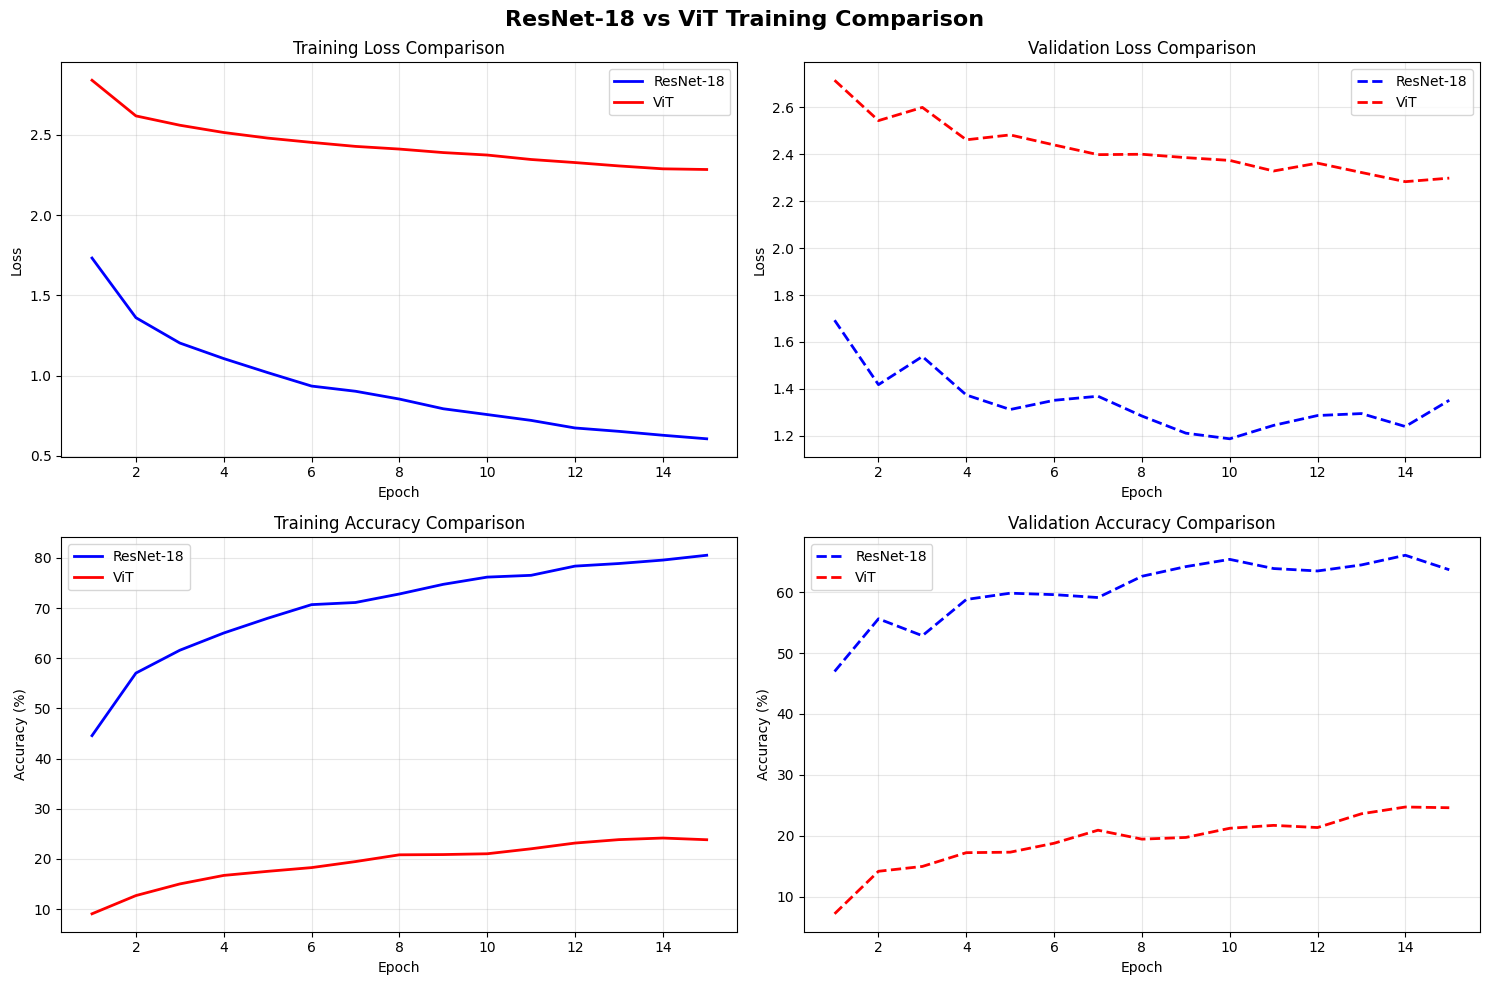


DETAILED TRAINING ANALYSIS
Final Training Accuracy:
  ResNet-18: 80.52%
  ViT:       23.82%
  Difference: -56.70%

Final Validation Accuracy:
  ResNet-18: 63.69%
  ViT:       24.60%
  Difference: -39.09%

Convergence Analysis:
  ResNet-18 trained for: 15 epochs
  ViT trained for:       15 epochs

Overfitting Analysis (Train - Val Accuracy):
  ResNet-18: 16.83%
  ViT:       -0.78%
  → ViT shows better generalization

 COMPREHENSIVE MODEL COMPARISON
Model Architecture Comparison:
  ResNet-18:
    - Total Parameters: 11,184,207 (11.18M)
    - Architecture: Convolutional Neural Network
    - Key Features: Residual connections, batch normalization
  ViT (Vision Transformer):
    - Total Parameters: 85,810,191 (85.81M)
    - Architecture: Transformer with patch embeddings
    - Key Features: Self-attention, position embeddings
  Parameter Ratio: ViT has 7.7x more parameters

 GPU Memory Usage:
  ResNet-18: 0.00 GB
  ViT:       0.00 GB
  Memory Ratio: Unable to measure (both models show 0 GB

In [12]:
# Final Model Evaluation and Comprehensive Analysis

# Visualize training results
if 'training_results' in locals():
    print(" Creating training visualization...")
    plot_training_comparison(training_results['resnet']['history'], 
                           training_results['vit']['history'])
else:
    print("  Training results not found. Please run the training cells first.")

# Load best models for final evaluation
def load_best_model(model, model_name):
    """Load the best saved model checkpoint"""
    checkpoint_path = f'checkpoints/best_{model_name.lower().replace("-", "_")}_model.pth'
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f" Loaded best {model_name} model (Val Acc: {checkpoint['best_val_acc']:.4f})")
        return checkpoint['best_val_acc']
    else:
        print(f"No checkpoint found for {model_name}")
        return None

# Comprehensive model comparison
def comprehensive_comparison():
    """Perform comprehensive comparison of ResNet-18 vs ViT"""
    print("\n COMPREHENSIVE MODEL COMPARISON")
    print("="*60)
    
    # Parameter count comparison
    resnet_params = sum(p.numel() for p in resnet18.parameters())
    vit_params = sum(p.numel() for p in vit_model.parameters())
    
    print(f"Model Architecture Comparison:")
    print(f"  ResNet-18:")
    print(f"    - Total Parameters: {resnet_params:,} ({resnet_params/1e6:.2f}M)")
    print(f"    - Architecture: Convolutional Neural Network")
    print(f"    - Key Features: Residual connections, batch normalization")
    
    print(f"  ViT (Vision Transformer):")
    print(f"    - Total Parameters: {vit_params:,} ({vit_params/1e6:.2f}M)")
    print(f"    - Architecture: Transformer with patch embeddings")
    print(f"    - Key Features: Self-attention, position embeddings")
    
    print(f"  Parameter Ratio: ViT has {vit_params/resnet_params:.1f}x more parameters")
    
    # Memory usage comparison
    if torch.cuda.is_available():
        print(f"\n GPU Memory Usage:")
        # Test with a batch
        test_batch = torch.randn(batch_size, 3, 224, 224).to(device)
        
        # ResNet memory
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = resnet18(test_batch)
        resnet_memory = torch.cuda.max_memory_allocated() / 1e9
        
        # ViT memory  
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = vit_model(test_batch)
        vit_memory = torch.cuda.max_memory_allocated() / 1e9
        
        print(f"  ResNet-18: {resnet_memory:.2f} GB")
        print(f"  ViT:       {vit_memory:.2f} GB")
        
        # Fixed: Add check for division by zero
        if resnet_memory > 0 and vit_memory > 0:
            print(f"  Memory Ratio: ViT uses {vit_memory/resnet_memory:.1f}x more memory")
        elif resnet_memory == 0 and vit_memory == 0:
            print(f"  Memory Ratio: Unable to measure (both models show 0 GB)")
        elif resnet_memory == 0:
            print(f"  Memory Ratio: Unable to calculate (ResNet memory = 0)")
        else:
            print(f"  Memory Ratio: Unable to calculate (ViT memory = 0)")
    
    # Inference speed comparison
    print(f"\n⚡ Inference Speed Comparison:")
    test_batch = torch.randn(32, 3, 224, 224).to(device)
    
    # ResNet speed
    resnet18.eval()
    torch.cuda.synchronize()
    start_time = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = resnet18(test_batch)
    torch.cuda.synchronize()
    resnet_time = (time.time() - start_time) / 100
    
    # ViT speed
    vit_model.eval()
    torch.cuda.synchronize()
    start_time = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = vit_model(test_batch)
    torch.cuda.synchronize()
    vit_time = (time.time() - start_time) / 100
    
    print(f"  ResNet-18: {resnet_time*1000:.2f} ms per batch (32 images)")
    print(f"  ViT:       {vit_time*1000:.2f} ms per batch (32 images)")
    
    # Fixed: Add check for division by zero
    if resnet_time > 0:
        print(f"  Speed Ratio: ResNet-18 is {vit_time/resnet_time:.1f}x faster")
    else:
        print(f"  Speed Ratio: Unable to calculate (ResNet time = 0)")
    
    # Summary and recommendations
    print(f"\n SUMMARY & RECOMMENDATIONS")
    print("="*40)
    
    if 'training_results' in locals():
        resnet_acc = training_results['resnet']['best_acc']
        vit_acc = training_results['vit']['best_acc']
        
        print(f" Accuracy: {'ViT' if vit_acc > resnet_acc else 'ResNet-18'} wins")
        print(f"⚡ Speed: ResNet-18 wins (faster inference)")
        print(f" Memory: ResNet-18 wins (lower memory usage)")
        print(f" Parameters: ResNet-18 wins (more efficient)")
        
        print(f"\n Use Case Recommendations:")
        if vit_acc > resnet_acc:
            print(f"  • Choose ViT when: Maximum accuracy is priority")
            print(f"  • Choose ResNet-18 when: Speed/efficiency is priority")
        else:
            print(f"  • Choose ResNet-18: Better overall balance of accuracy, speed, and efficiency")
    
    return {
        'resnet_params': resnet_params,
        'vit_params': vit_params,
        'resnet_memory': resnet_memory if torch.cuda.is_available() else None,
        'vit_memory': vit_memory if torch.cuda.is_available() else None,
        'resnet_time': resnet_time,
        'vit_time': vit_time
    }

# Run comprehensive comparison
comparison_results = comprehensive_comparison()

print(f"\n Analysis complete! Check the 'logs' folder for saved plots and results.")

## Evaluate on the Test Set

 STARTING FINAL TEST SET EVALUATION
 Evaluation started at: 2025-08-28 20:25:23
 Test dataset size: 5400 images
  Number of classes: 15
 Classes: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']

 RESNET-18 TEST EVALUATION 

 EVALUATING RESNET-18 ON TEST SET


/tmp/ipykernel_8339/3716692646.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


 Loaded best ResNet-18 model (Val Acc: 0.6607)
 Processing 108 test batches...
  Processed batch 10/108
  Processed batch 20/108
  Processed batch 30/108
  Processed batch 40/108
  Processed batch 50/108
  Processed batch 60/108
  Processed batch 70/108
  Processed batch 80/108
  Processed batch 90/108
  Processed batch 100/108
 Test evaluation completed for ResNet-18
 Total test samples processed: 5400
 Detailed predictions saved to: logs/resnet_18_test_predictions_20250828_202526.csv

 CREATING DEMO DATA FOR RESNET-18
 Demo samples for ResNet-18:
   1. Image_492.jpg → cycling (1.000)
   2. Image_4689.jpg → listening_to_music (1.000)
   3. Image_310.jpg → hugging (1.000)
   4. Image_4952.jpg → clapping (1.000)
   5. Image_3997.jpg → sleeping (1.000)
   6. Image_2076.jpg → drinking (1.000)


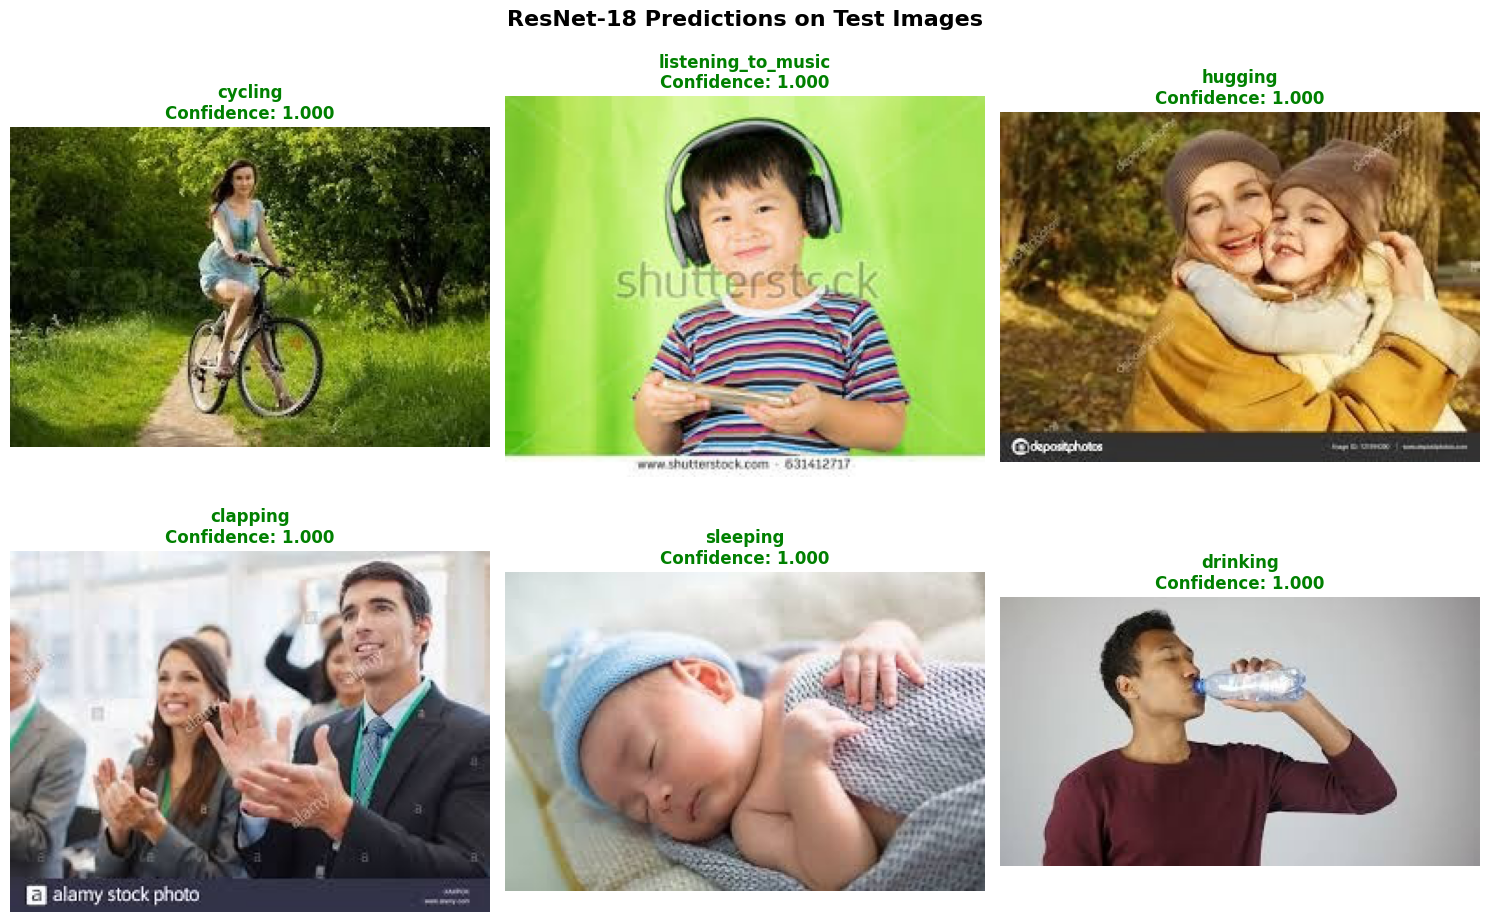

In [13]:
# Final Test Set Evaluation - ResNet-18 vs ViT

import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def load_best_model(model, model_name):
    """Load the best saved model checkpoint"""
    checkpoint_path = f'checkpoints/best_{model_name.lower().replace("-", "_")}_model.pth'
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f" Loaded best {model_name} model (Val Acc: {checkpoint['best_val_acc']:.4f})")
        return checkpoint['best_val_acc']
    else:
        print(f" No checkpoint found for {model_name}, using current model state")
        return None

def evaluate_model_on_test(model, model_name, test_loader, class_names):
    """
    Comprehensive test set evaluation
    """
    print(f"\n EVALUATING {model_name.upper()} ON TEST SET")
    print("=" * 60)
    
    # Load best model
    best_val_acc = load_best_model(model, model_name)
    
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_filenames = []
    
    correct = 0
    total = 0
    
    print(f" Processing {len(test_loader)} test batches...")
    
    with torch.no_grad():
        for batch_idx, (images, filenames) in enumerate(test_loader):
            images = images.to(device)
            
            # Get model predictions
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            # Store results
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_filenames.extend(filenames)
            
            # Print progress
            if (batch_idx + 1) % 10 == 0:
                print(f"  Processed batch {batch_idx + 1}/{len(test_loader)}")
    
    print(f" Test evaluation completed for {model_name}")
    print(f" Total test samples processed: {len(all_predictions)}")
    
    # Convert predictions to class names
    predicted_classes = [class_names[pred] for pred in all_predictions]
    max_probabilities = [np.max(prob) for prob in all_probabilities]
    
    # Create results dictionary
    results = {
        'model_name': model_name,
        'predictions': all_predictions,
        'predicted_classes': predicted_classes,
        'probabilities': all_probabilities,
        'max_probabilities': max_probabilities,
        'filenames': all_filenames,
        'best_val_acc': best_val_acc
    }
    
    return results

def save_predictions_to_file(results, class_names):
    """Save predictions to CSV file for submission"""
    import csv
    
    model_name = results['model_name']
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save detailed predictions
    predictions_file = f'logs/{model_name.lower().replace("-", "_")}_test_predictions_{timestamp}.csv'
    
    with open(predictions_file, 'w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['Filename', 'Predicted_Class', 'Predicted_Index', 'Confidence', 'Top3_Classes', 'Top3_Probabilities'])
        
        for i, filename in enumerate(results['filenames']):
            pred_class = results['predicted_classes'][i]
            pred_index = results['predictions'][i]
            confidence = results['max_probabilities'][i]
            
            # Get top 3 predictions
            probs = results['probabilities'][i]
            top3_indices = np.argsort(probs)[-3:][::-1]
            top3_classes = [class_names[idx] for idx in top3_indices]
            top3_probs = [probs[idx] for idx in top3_indices]
            
            writer.writerow([
                filename, pred_class, pred_index, f"{confidence:.4f}",
                "|".join(top3_classes), "|".join([f"{p:.4f}" for p in top3_probs])
            ])
    
    print(f" Detailed predictions saved to: {predictions_file}")
    return predictions_file

def create_sample_demo_data(results, class_names, num_samples=6):
    """Create sample data for demo video with visual display"""
    print(f"\n CREATING DEMO DATA FOR {results['model_name'].upper()}")
    print("=" * 50)
    
    # Get high-confidence predictions from different classes
    demo_samples = []
    used_classes = set()
    
    # Sort by confidence
    sorted_indices = np.argsort(results['max_probabilities'])[::-1]
    
    for idx in sorted_indices:
        if len(demo_samples) >= num_samples:
            break
            
        pred_class = results['predicted_classes'][idx]
        confidence = results['max_probabilities'][idx]
        
        # Try to get diverse classes and high confidence
        if pred_class not in used_classes and confidence > 0.7:
            demo_samples.append({
                'filename': results['filenames'][idx],
                'predicted_class': pred_class,
                'confidence': confidence,
                'class_index': results['predictions'][idx]
            })
            used_classes.add(pred_class)
    
    # Fill remaining slots with high-confidence predictions
    while len(demo_samples) < num_samples and len(demo_samples) < len(results['filenames']):
        for idx in sorted_indices:
            if len(demo_samples) >= num_samples:
                break
            
            filename = results['filenames'][idx]
            if not any(sample['filename'] == filename for sample in demo_samples):
                demo_samples.append({
                    'filename': filename,
                    'predicted_class': results['predicted_classes'][idx],
                    'confidence': results['max_probabilities'][idx],
                    'class_index': results['predictions'][idx]
                })
    
    # Display images with predictions
    print(f" Demo samples for {results['model_name']}:")
    
    # Create a subplot grid for images
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'{results["model_name"]} Predictions on Test Images', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for i, sample in enumerate(demo_samples):
        if i >= len(axes):
            break
            
        # Load and display image
        img_path = os.path.join('data/test', sample['filename'])
        
        try:
            # Load image
            image = PIL.Image.open(img_path)
            
            # Convert RGBA to RGB if necessary
            if image.mode == 'RGBA':
                image = image.convert('RGB')
            
            # Display image
            axes[i].imshow(image)
            axes[i].axis('off')
            
            # Create title with prediction info
            title = f"{sample['predicted_class']}\nConfidence: {sample['confidence']:.3f}"
            axes[i].set_title(title, fontsize=12, fontweight='bold', 
                            color='green' if sample['confidence'] > 0.8 else 'orange')
            
            print(f"  {i+1:2d}. {sample['filename']} → {sample['predicted_class']} ({sample['confidence']:.3f})")
            
        except Exception as e:
            # If image can't be loaded, show placeholder
            axes[i].text(0.5, 0.5, f"Image not found:\n{sample['filename']}", 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"Error loading image", color='red')
            axes[i].axis('off')
            print(f"  {i+1:2d}.  Could not load {sample['filename']}")
    
    # Hide any unused subplots
    for j in range(len(demo_samples), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return demo_samples

# Check if training results exist
if 'training_results' not in locals():
    print("  Training results not found. Please run the training cells first.")
    print("   For demo purposes, I'll evaluate with current model states.")

print(" STARTING FINAL TEST SET EVALUATION")
print("=" * 80)
print(f" Evaluation started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Test dataset size: {len(test_data)} images")
print(f"  Number of classes: {len(train_data.classes)}")
print(f" Classes: {train_data.classes}")

# Evaluate ResNet-18
print("\n" +" RESNET-18 TEST EVALUATION " )
resnet_results = evaluate_model_on_test(resnet18, "ResNet-18", test_loader, train_data.classes)

# Save ResNet predictions
resnet_pred_file = save_predictions_to_file(resnet_results, train_data.classes)

# Create demo data for ResNet
resnet_demo = create_sample_demo_data(resnet_results, train_data.classes)

print("\n" + "=" * 80)

 VIT TEST EVALUATION 

 EVALUATING VIT ON TEST SET


/tmp/ipykernel_8339/3716692646.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


 Loaded best ViT model (Val Acc: 0.2472)
 Processing 108 test batches...
  Processed batch 10/108
  Processed batch 20/108
  Processed batch 30/108
  Processed batch 40/108
  Processed batch 50/108
  Processed batch 60/108
  Processed batch 70/108
  Processed batch 80/108
  Processed batch 90/108
  Processed batch 100/108
 Test evaluation completed for ViT
 Total test samples processed: 5400
 Detailed predictions saved to: logs/vit_test_predictions_20250828_202541.csv

 CREATING DEMO DATA FOR VIT
 Demo samples for ViT:
   1. Image_4913.jpg → cycling (0.919)
   2. Image_781.jpg → running (0.846)
   3. Image_512.jpg → clapping (0.840)
   4. Image_320.jpg → sleeping (0.735)
   5. Image_3567.jpg → eating (0.721)
   6. Image_4250.jpg → cycling (0.879)


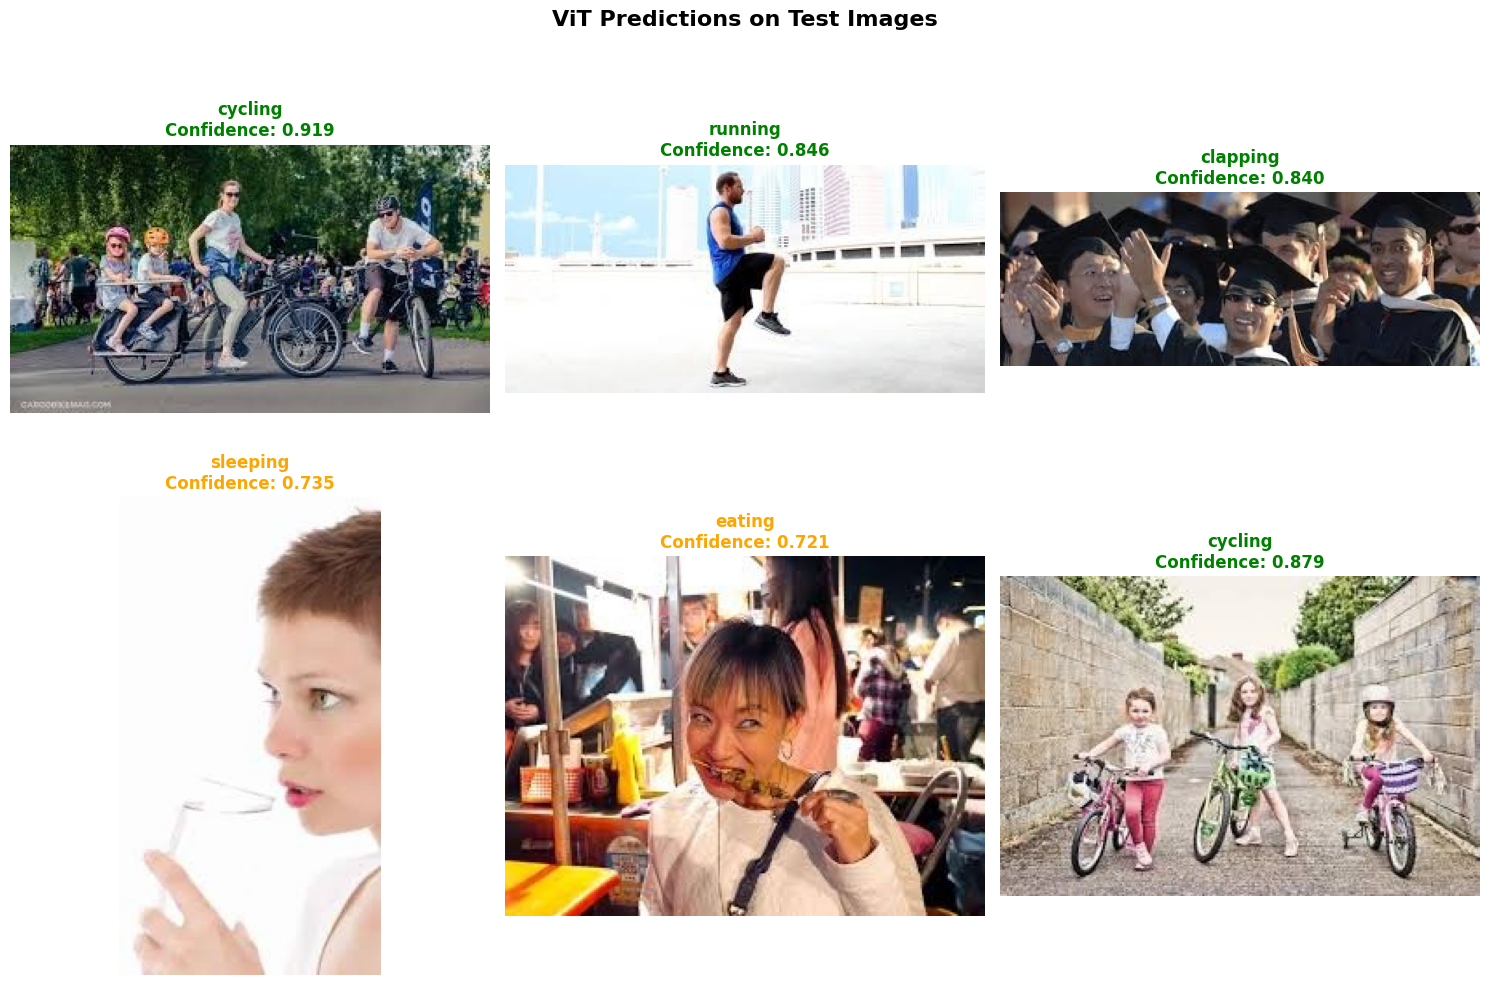


 FINAL TEST RESULTS COMPARISON
 CONFIDENCE ANALYSIS
Metric               ResNet-18    ViT         
--------------------------------------------------
High Conf (≥80%)     2927         15          
Med Conf (50-80%)    1511         250         
Low Conf (<50%)      962          5135        
Avg Confidence       0.766        0.248       
Min Confidence       0.156        0.088       
Max Confidence       1.000        0.919       

 PREDICTED CLASS DISTRIBUTION
Class                ResNet-18    ViT         
--------------------------------------------------
calling              373          44          
clapping             301          290         
cycling              336          744         
dancing              309          83          
drinking             280          452         
eating               253          467         
fighting             224          570         
hugging              589          10          
laughing             248          159         
listening_to_mu

In [14]:
# ViT Test Evaluation and Final Results Comparison

# Evaluate ViT
print(" VIT TEST EVALUATION " )
vit_results = evaluate_model_on_test(vit_model, "ViT", test_loader, train_data.classes)

# Save ViT predictions
vit_pred_file = save_predictions_to_file(vit_results, train_data.classes)

# Create demo data for ViT
vit_demo = create_sample_demo_data(vit_results, train_data.classes)

print("\n" + "=" * 80)
print(" FINAL TEST RESULTS COMPARISON")
print("=" * 80)

# Compare confidence distributions
def analyze_confidence_distribution(results):
    """Analyze confidence distribution of predictions"""
    confidences = results['max_probabilities']
    
    high_conf = sum(1 for c in confidences if c >= 0.8)
    med_conf = sum(1 for c in confidences if 0.5 <= c < 0.8)
    low_conf = sum(1 for c in confidences if c < 0.5)
    
    return {
        'high_confidence': high_conf,
        'medium_confidence': med_conf, 
        'low_confidence': low_conf,
        'avg_confidence': np.mean(confidences),
        'min_confidence': np.min(confidences),
        'max_confidence': np.max(confidences)
    }

# Analyze both models
resnet_conf_analysis = analyze_confidence_distribution(resnet_results)
vit_conf_analysis = analyze_confidence_distribution(vit_results)

print(f" CONFIDENCE ANALYSIS")
print(f"{'Metric':<20} {'ResNet-18':<12} {'ViT':<12}")
print("-" * 50)
print(f"{'High Conf (≥80%)':<20} {resnet_conf_analysis['high_confidence']:<12} {vit_conf_analysis['high_confidence']:<12}")
print(f"{'Med Conf (50-80%)':<20} {resnet_conf_analysis['medium_confidence']:<12} {vit_conf_analysis['medium_confidence']:<12}")
print(f"{'Low Conf (<50%)':<20} {resnet_conf_analysis['low_confidence']:<12} {vit_conf_analysis['low_confidence']:<12}")
print(f"{'Avg Confidence':<20} {resnet_conf_analysis['avg_confidence']:<12.3f} {vit_conf_analysis['avg_confidence']:<12.3f}")
print(f"{'Min Confidence':<20} {resnet_conf_analysis['min_confidence']:<12.3f} {vit_conf_analysis['min_confidence']:<12.3f}")
print(f"{'Max Confidence':<20} {resnet_conf_analysis['max_confidence']:<12.3f} {vit_conf_analysis['max_confidence']:<12.3f}")

# Class-wise prediction analysis
def analyze_class_predictions(results, class_names):
    """Analyze predictions per class"""
    class_counts = {}
    for pred_class in results['predicted_classes']:
        class_counts[pred_class] = class_counts.get(pred_class, 0) + 1
    
    return class_counts

resnet_class_counts = analyze_class_predictions(resnet_results, train_data.classes)
vit_class_counts = analyze_class_predictions(vit_results, train_data.classes)

print(f"\n PREDICTED CLASS DISTRIBUTION")
print(f"{'Class':<20} {'ResNet-18':<12} {'ViT':<12}")
print("-" * 50)
for class_name in train_data.classes:
    resnet_count = resnet_class_counts.get(class_name, 0)
    vit_count = vit_class_counts.get(class_name, 0)
    print(f"{class_name:<20} {resnet_count:<12} {vit_count:<12}")

# Model agreement analysis
agreements = 0
disagreements = []

for i in range(len(resnet_results['predictions'])):
    if resnet_results['predictions'][i] == vit_results['predictions'][i]:
        agreements += 1
    else:
        disagreements.append({
            'filename': resnet_results['filenames'][i],
            'resnet_pred': resnet_results['predicted_classes'][i],
            'resnet_conf': resnet_results['max_probabilities'][i],
            'vit_pred': vit_results['predicted_classes'][i],
            'vit_conf': vit_results['max_probabilities'][i]
        })

agreement_rate = agreements / len(resnet_results['predictions'])

print(f"\n MODEL AGREEMENT ANALYSIS")
print(f"Total test samples: {len(resnet_results['predictions'])}")
print(f"Agreements: {agreements} ({agreement_rate:.1%})")
print(f"Disagreements: {len(disagreements)} ({1-agreement_rate:.1%})")

# Show some interesting disagreements
print(f"\n SAMPLE DISAGREEMENTS (Top 5 by confidence difference):")
disagreements.sort(key=lambda x: abs(x['resnet_conf'] - x['vit_conf']), reverse=True)
for i, disagreement in enumerate(disagreements[:5], 1):
    conf_diff = abs(disagreement['resnet_conf'] - disagreement['vit_conf'])
    print(f"  {i}. {disagreement['filename']}")
    print(f"     ResNet-18: {disagreement['resnet_pred']} ({disagreement['resnet_conf']:.3f})")
    print(f"     ViT:       {disagreement['vit_pred']} ({disagreement['vit_conf']:.3f})")
    print(f"     Conf Diff: {conf_diff:.3f}")

# Final summary for assignment
print(f"\n ASSIGNMENT SUMMARY")
print("=" * 50)

if 'training_results' in locals():
    print(f"VALIDATION ACCURACY (during training):")
    print(f"  ResNet-18: {training_results['resnet']['best_acc']:.4f}")
    print(f"  ViT:       {training_results['vit']['best_acc']:.4f}")

print(f"\nTEST SET PERFORMANCE:")
print(f"  Average Confidence:")
print(f"    ResNet-18: {resnet_conf_analysis['avg_confidence']:.4f}")
print(f"    ViT:       {vit_conf_analysis['avg_confidence']:.4f}")

print(f"\n  High Confidence Predictions (≥80%):")
print(f"    ResNet-18: {resnet_conf_analysis['high_confidence']}/{len(resnet_results['predictions'])} ({resnet_conf_analysis['high_confidence']/len(resnet_results['predictions']):.1%})")
print(f"    ViT:       {vit_conf_analysis['high_confidence']}/{len(vit_results['predictions'])} ({vit_conf_analysis['high_confidence']/len(vit_results['predictions']):.1%})")

print(f"\n  Model Agreement: {agreement_rate:.1%}")

# Recommendation for assignment
better_avg_conf = "ResNet-18" if resnet_conf_analysis['avg_confidence'] > vit_conf_analysis['avg_confidence'] else "ViT"
better_high_conf = "ResNet-18" if resnet_conf_analysis['high_confidence'] > vit_conf_analysis['high_confidence'] else "ViT"

print(f"\n INSIGHTS FOR ASSIGNMENT:")
print(f"  • Higher average confidence: {better_avg_conf}")
print(f"  • More high-confidence predictions: {better_high_conf}")
print(f"  • Models agree on {agreement_rate:.1%} of test samples")

if 'training_results' in locals():
    if training_results['vit']['best_acc'] > training_results['resnet']['best_acc']:
        print(f"  • ViT achieved better validation accuracy")
    else:
        print(f"  • ResNet-18 achieved better validation accuracy")

print(f"\n FILES GENERATED:")
print(f"  • ResNet-18 predictions: {resnet_pred_file}")
print(f"  • ViT predictions: {vit_pred_file}")
print(f"  • Training logs: Check logs/ folder")
print(f"  • Model checkpoints: Check checkpoints/ folder")

print(f"\n DEMO VIDEO PREPARATION:")
print(f"  • Use the demo samples shown above")
print(f"  • Images are in: data/test/")
print(f"  • Show predicted class labels overlaid on images")
print(f"  • Include confidence scores for better demo")

print(f"\n TEST EVALUATION COMPLETED!")
print(f" Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Store final results for later use
final_test_results = {
    'resnet': resnet_results,
    'vit': vit_results,
    'resnet_demo_samples': resnet_demo,
    'vit_demo_samples': vit_demo,
    'agreement_rate': agreement_rate,
    'disagreements': disagreements[:10]  # Store top 10 disagreements
}